# NBD 補正後の 3状態 Bass 拡張モデル

先の NBD 分析で得られた **潜在市場 M_latent(t) = 閾値効果除去後の真のプレイヤー数** を観測値として、3状態 Bass 拡張モデル（p₁(t), p₂(t) 時変）を推定する。

従来の `Pachinko_3State_P1tP2t` では「年1回以上」の閾値で定義された観測アクティブ数を使っていた。これには閾値効果（低頻度層の統計的出入り）が混入し、p₁ と p₂ の分離困難を招いていた。

## 入力データ

| 年 | M_latent (万人) |
|---|---|
| 2008 | 1675.5 |
| 2011 | 1434.9 |
| 2012 | 1204.4 |
| 2013 | 1144.6 |
| 2014 | 1285.8 |
| 2015 | 1228.0 |
| 2016 | 1014.5 |
| 2018 | 1041.7 |
| 2019 | 1083.6 |

N=9（年）と少ないため、事前分布を強めに設定する。

In [1]:
ENV["GKS_ENCODING"] = "utf8"
using DifferentialEquations, Turing, Distributions
using DataFrames, CSV, Plots, StatsPlots, Statistics, Printf, Random
gr(fontfamily="PlemolJP-Text")
Random.seed!(20260415);

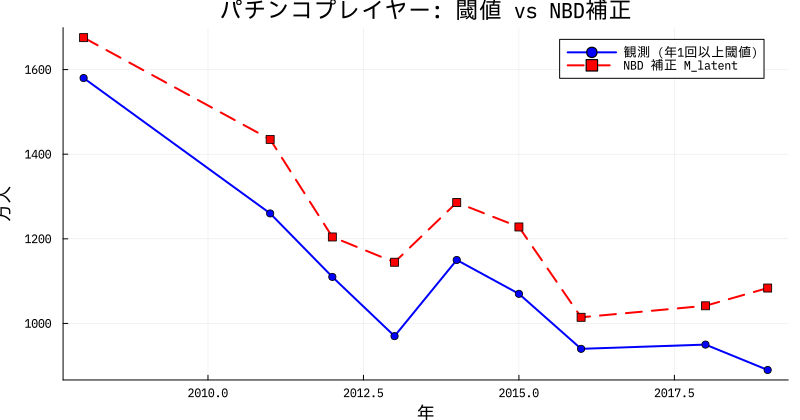

In [2]:
# NBD 補正後の M_latent(t)
df = DataFrame(
    年 = [2008, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019],
    M_latent = [1675.5, 1434.96, 1204.4, 1144.61, 1285.79, 1228.03, 1014.51, 1041.72, 1083.63]
)
t_obs = Float64.(df.年)
A_obs = Float64.(df.M_latent)

# 比較用: 元の観測アクティブ数
A_raw = [1580.0, 1260.0, 1110.0, 970.0, 1150.0, 1070.0, 940.0, 950.0, 890.0]

plt = plot(t_obs, A_raw, marker=:circle, lw=2, color=:blue,
           label="観測 (年1回以上閾値)", xlabel="年", ylabel="万人",
           title="パチンコプレイヤー: 閾値 vs NBD補正", size=(800,420))
plot!(plt, t_obs, A_obs, marker=:square, lw=2, color=:red, ls=:dash,
      label="NBD 補正 M_latent")
plt

In [3]:
# 3状態 ODE: q2=0、p1(t), p2(t) ガウス
function bass_p1p2t!(du, u, params, t)
    s, a, x = u
    p1_b, A1, c1, w1, p2_b, A2, c2, w2, q1, α = params
    s = clamp(s, 0.0, 1.0); a = clamp(a, 0.0, 1.0); x = clamp(x, 0.0, 1.0)
    p1_t = p1_b + A1 * exp(-0.5 * ((t - c1)/w1)^2)
    p2_t = p2_b + A2 * exp(-0.5 * ((t - c2)/w2)^2)
    adoption = p1_t + q1 * a
    f_in      = adoption * s
    f_readopt = α * adoption * x
    f_out     = p2_t * a
    du[1] = -f_in
    du[2] = f_in + f_readopt - f_out
    du[3] = f_out - f_readopt
end

function solve_bass(p1_b, A1, c1, w1, p2_b, A2, c2, w2, q1, α, M, a0, t_eval)
    u0 = [1.0 - a0, a0, 0.0]
    tspan = (t_eval[1] - 1.0, t_eval[end] + 1.0)
    params = (p1_b, A1, c1, w1, p2_b, A2, c2, w2, q1, α)
    prob = ODEProblem(bass_p1p2t!, u0, tspan, params)
    sol = solve(prob, Tsit5(); saveat=t_eval, abstol=1e-6, reltol=1e-6, maxiters=50_000)
    T = promote_type(typeof(p1_b), typeof(A1), typeof(c1), typeof(w1),
                     typeof(p2_b), typeof(A2), typeof(c2), typeof(w2),
                     typeof(q1), typeof(α), typeof(M))
    A_pred = zeros(T, length(t_eval))
    for i in eachindex(t_eval)
        a_i = i <= length(sol.t) ? sol.u[i][2] : zero(T)
        A_pred[i] = M * a_i
    end
    return A_pred
end;

In [4]:
# Turing モデル
@model function pachinko_nbd_bass(t_eval, A_obs, a0)
    # p1(t): 成長期ショック（過去の 2001 付近のブーム残余を想定、2008以前）
    p1_base ~ Uniform(0.0, 0.15)
    A1      ~ Uniform(0.0, 0.3)
    c1      ~ Uniform(2005.0, 2012.0)
    w1      ~ Uniform(0.5, 5.0)
    # p2(t): 衰退期ショック（スマホ普及 2013-2016 想定）
    p2_base ~ Uniform(0.0, 0.3)
    A2      ~ Uniform(0.0, 0.5)
    c2      ~ Uniform(2012.0, 2019.0)
    w2      ~ Uniform(0.5, 5.0)
    # 定数
    q1      ~ Uniform(0.0, 2.0)
    α       ~ Uniform(0.0, 1.0)
    M       ~ Uniform(1500.0, 5000.0)   # 万人（真の潜在市場）
    σ       ~ Uniform(20.0, 500.0)

    A_pred = solve_bass(p1_base, A1, c1, w1, p2_base, A2, c2, w2, q1, α, M, a0, t_eval)
    for i in eachindex(t_eval)
        A_obs[i] ~ Normal(A_pred[i], σ)
    end
end;

In [5]:
# MCMC
a0_init = A_obs[1] / 2500.0
model = pachinko_nbd_bass(t_obs, A_obs, a0_init)

init_vals = (; p1_base=0.02, A1=0.05, c1=2008.0, w1=2.0,
              p2_base=0.05, A2=0.15, c2=2015.0, w2=2.0,
              q1=0.5, α=0.3, M=2500.0, σ=100.0)
n_chains = 4

@time chain = sample(model, NUTS(0.9; max_depth=10), MCMCThreads(), 1000, n_chains;
                     initial_params=fill(init_vals, n_chains))

[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC C:\Users\kimse\.julia\packages\AbstractMCMC\oqm6Y\src\sample.jl:544
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (1 thread):  25%|████████                      |  ETA: 0:00:29┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (1 thread):  50%|████████████████              |  ETA: 0:00:32┌ Info: Found initial step size
└   ϵ = 0.2
Sampling 

 87.956053 seconds (294.99 M allocations: 26.474 GiB, 6.60% gc time, 45.93% compilation time: 3% of which was recompilation)


Chains MCMC chain (1000×26×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 67.33 seconds
Compute duration  = 57.8 seconds
parameters        = p1_base, A1, c1, w1, p2_base, A2, c2, w2, q1, α, M, σ
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Use `describe(chains)` for summary statistics and quantiles.


In [9]:
ENV["COLUMNS"] = "200"
display(summarize(chain))



  parameters        mean        std      mcse    ess_bulk    ess_tail      rhat   ess_per_sec 
      Symbol     Float64    Float64   Float64     Float64     Float64   Float64       Float64 

     p1_base      0.0808     0.0437    0.0007   4035.0175   2238.8549    1.0010       69.8052
          A1      0.1460     0.0851    0.0013   4036.3181   2638.5131    1.0014       69.8277
          c1   2008.4176     2.0385    0.0339   3548.2018   2277.3707    1.0024       61.3833
          w1      2.8044     1.3152    0.0213   3642.2472   1787.1709    1.0015       63.0103
     p2_base      0.1946     0.0746    0.0016   1915.8066   1793.3542    1.0019       33.1431
          A2      0.1520     0.1266    0.0030   1917.6068   2320.9593    1.0031       33.1743
          c2   2015.0585     1.7899    0.0385   2338.4240   2064.2174    1.0042       40.4544
          w2      3.2998     1.2948    0.0259   2647.9956   2688.5470    1.0016       45.8099
          q1      1.0695     0.5502    0.0123   2006.33

In [6]:
# Quantile 表
param_names = [:p1_base, :A1, :c1, :w1, :p2_base, :A2, :c2, :w2, :q1, :α, :M, :σ]
println("=== 事後分布 Quantile (NBD-Bass) ===")
@printf("%-10s %10s %10s %10s %10s %10s %10s\n",
        "param", "2.5%", "25%", "50%", "75%", "97.5%", "CI/med")
for p in param_names
    v = vec(Array(chain[p]))
    q = quantile(v, [0.025, 0.25, 0.5, 0.75, 0.975])
    ci_ratio = (q[5] - q[1]) / abs(q[3])
    mark = ci_ratio < 1.0 ? "○" : ci_ratio < 2.0 ? "△" : "✗"
    @printf("%-10s %10.4g %10.4g %10.4g %10.4g %10.4g %8.2f %s\n",
            string(p), q[1], q[2], q[3], q[4], q[5], ci_ratio, mark)
end

=== 事後分布 Quantile (NBD-Bass) ===
param            2.5%        25%        50%        75%      97.5%     CI/med
p1_base      0.004745    0.04214    0.08384     0.1195     0.1473     1.70 △
A1           0.007344    0.07243     0.1464     0.2185     0.2909     1.94 △
c1               2005       2007       2008       2010       2012     0.00 ○
w1             0.6136      1.648      2.825      3.969      4.889     1.51 △
p2_base       0.03149      0.143     0.2082      0.258     0.2962     1.27 △
A2           0.005087    0.05066     0.1156     0.2247     0.4556     3.90 ✗
c2               2012       2014       2015       2016       2019     0.00 ○
w2             0.6455      2.381      3.632      4.391      4.934     1.18 △
q1            0.08583     0.6204      1.081      1.541      1.953     1.73 △
α              0.1454     0.3303     0.4883     0.6973     0.9649     1.68 △
M                1670       2006       2191       2402       2847     0.54 ○
σ               65.48      91.54      115.3

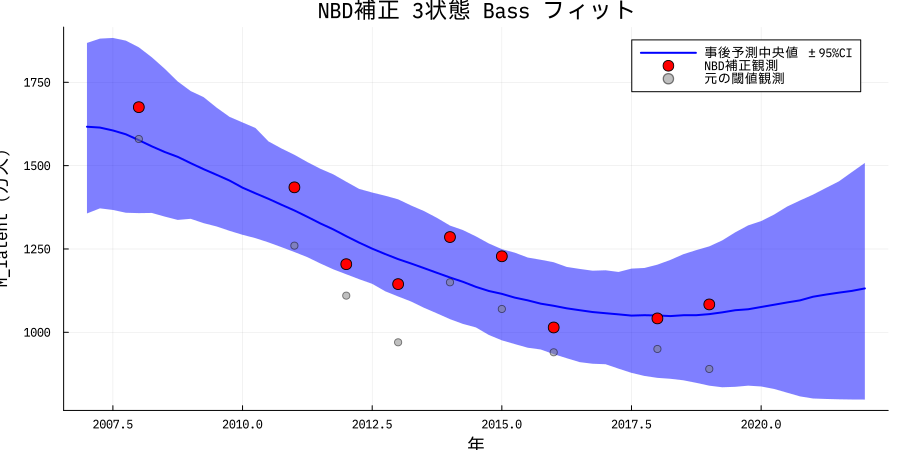

In [7]:
# 事後予測
n_post = 400
idx = rand(1:size(chain, 1) * size(chain, 3), n_post)
arr = Array(chain); cn = names(chain)
col(p) = findfirst(==(p), cn)

t_grid = collect(2007.0:0.25:2022.0)
preds = zeros(n_post, length(t_grid))
for k in 1:n_post
    i = idx[k]
    p1b=arr[i,col(:p1_base)]; A1=arr[i,col(:A1)]; c1=arr[i,col(:c1)]; w1=arr[i,col(:w1)]
    p2b=arr[i,col(:p2_base)]; A2=arr[i,col(:A2)]; c2=arr[i,col(:c2)]; w2=arr[i,col(:w2)]
    q1=arr[i,col(:q1)]; α=arr[i,col(:α)]; M=arr[i,col(:M)]
    preds[k, :] = solve_bass(p1b,A1,c1,w1,p2b,A2,c2,w2,q1,α,M,a0_init,t_grid)
end
med = [quantile(preds[:,j], 0.5) for j in 1:length(t_grid)]
lo  = [quantile(preds[:,j], 0.025) for j in 1:length(t_grid)]
hi  = [quantile(preds[:,j], 0.975) for j in 1:length(t_grid)]

plt = plot(t_grid, med, ribbon=(med .- lo, hi .- med), lw=2, color=:blue,
           label="事後予測中央値 ±95%CI", xlabel="年", ylabel="M_latent (万人)",
           title="NBD補正 3状態 Bass フィット", size=(900,450))
scatter!(plt, t_obs, A_obs, color=:red, ms=6, label="NBD補正観測")
scatter!(plt, t_obs, A_raw, color=:gray, ms=4, alpha=0.5, label="元の閾値観測")
plt

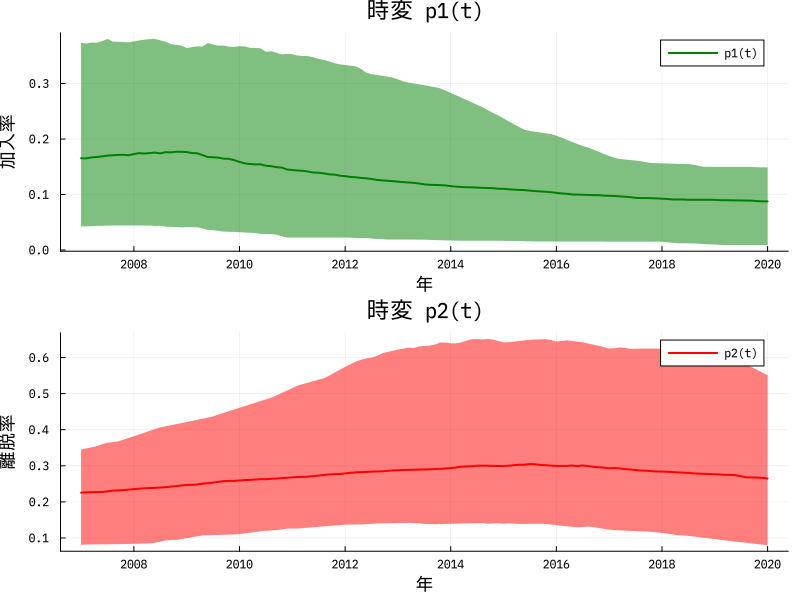

In [8]:
# p1(t), p2(t) の時系列
t_fine = collect(2007.0:0.1:2020.0)
p1_samples = zeros(n_post, length(t_fine))
p2_samples = zeros(n_post, length(t_fine))
for k in 1:n_post
    i = idx[k]
    p1b=arr[i,col(:p1_base)]; A1=arr[i,col(:A1)]; c1=arr[i,col(:c1)]; w1=arr[i,col(:w1)]
    p2b=arr[i,col(:p2_base)]; A2=arr[i,col(:A2)]; c2=arr[i,col(:c2)]; w2=arr[i,col(:w2)]
    for (j, t) in enumerate(t_fine)
        p1_samples[k,j] = p1b + A1*exp(-0.5*((t-c1)/w1)^2)
        p2_samples[k,j] = p2b + A2*exp(-0.5*((t-c2)/w2)^2)
    end
end
p1_m = [quantile(p1_samples[:,j],0.5) for j in 1:length(t_fine)]
p1_lo = [quantile(p1_samples[:,j],0.025) for j in 1:length(t_fine)]
p1_hi = [quantile(p1_samples[:,j],0.975) for j in 1:length(t_fine)]
p2_m = [quantile(p2_samples[:,j],0.5) for j in 1:length(t_fine)]
p2_lo = [quantile(p2_samples[:,j],0.025) for j in 1:length(t_fine)]
p2_hi = [quantile(p2_samples[:,j],0.975) for j in 1:length(t_fine)]

plt1 = plot(t_fine, p1_m, ribbon=(p1_m.-p1_lo, p1_hi.-p1_m), lw=2, color=:green,
            label="p1(t)", xlabel="年", ylabel="加入率", title="時変 p1(t)")
plt2 = plot(t_fine, p2_m, ribbon=(p2_m.-p2_lo, p2_hi.-p2_m), lw=2, color=:red,
            label="p2(t)", xlabel="年", ylabel="離脱率", title="時変 p2(t)")
plot(plt1, plt2, layout=(2,1), size=(800,600))

## 比較ポイント

従来の `Pachinko_3State_P1tP2t`（q2=0 版）推定値（参考）:
- M ≈ 3132 万人（CI/med 0.19）
- c2 ≈ 2014（スマホ期）
- A2: CI/med 2.4（識別✗）
- α: CI/med 1.5（識別△）

本 NBD 補正版で期待する違い:
- **p2_base/A2 の識別性改善**: 閾値効果を NBD が吸収したので、残る p₂ は真の離脱
- **c2 の位置シフト**: 真の行動変化（スマホで時間を取られる）の時期がより明確に
- **M の意味変化**: 「λ>0 の潜在プール」へ。絶対値は従来より小さくなるはず
- **データ点数 N=9 と少ない**: 事前の情報依存が強く、識別性判定は慎重に

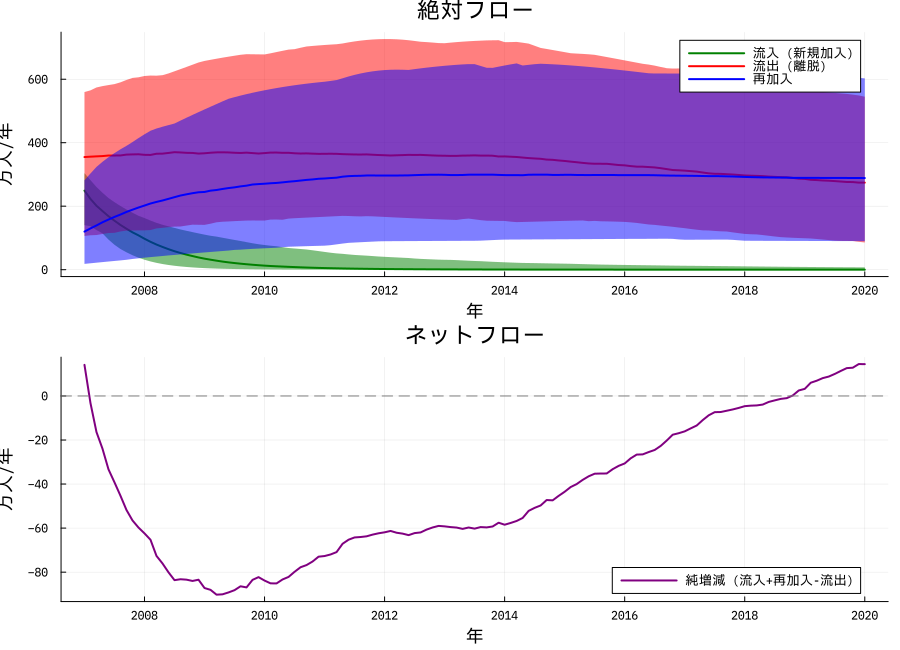

In [10]:
# 絶対フロー: 流入 = M·(p1(t)+q1·a(t))·s(t), 流出 = M·p2(t)·a(t), 再加入 = M·α·(p1+q1·a)·x
# ODE解 s(t), a(t), x(t) を事後サンプルごとに取得して積算
using DifferentialEquations

function sim_states(p1_b, A1, c1, w1, p2_b, A2, c2, w2, q1, α, a0, t_eval)
    u0 = [1.0 - a0, a0, 0.0]
    tspan = (t_eval[1] - 1.0, t_eval[end] + 1.0)
    params = (p1_b, A1, c1, w1, p2_b, A2, c2, w2, q1, α)
    prob = ODEProblem(bass_p1p2t!, u0, tspan, params)
    sol = solve(prob, Tsit5(); saveat=t_eval, abstol=1e-6, reltol=1e-6, maxiters=50_000)
    return sol
end

t_grid_flow = collect(2007.0:0.1:2020.0)
n_post = 400
idx = rand(1:size(chain,1)*size(chain,3), n_post)
arr = Array(chain); cn = names(chain)
col(p) = findfirst(==(p), cn)

inflow_samples  = zeros(n_post, length(t_grid_flow))
outflow_samples = zeros(n_post, length(t_grid_flow))
readopt_samples = zeros(n_post, length(t_grid_flow))
active_samples  = zeros(n_post, length(t_grid_flow))

for k in 1:n_post
    i = idx[k]
    p1b=arr[i,col(:p1_base)]; A1=arr[i,col(:A1)]; c1=arr[i,col(:c1)]; w1=arr[i,col(:w1)]
    p2b=arr[i,col(:p2_base)]; A2=arr[i,col(:A2)]; c2=arr[i,col(:c2)]; w2=arr[i,col(:w2)]
    q1=arr[i,col(:q1)]; α=arr[i,col(:α)]; M=arr[i,col(:M)]
    sol = sim_states(p1b,A1,c1,w1,p2b,A2,c2,w2,q1,α,a0_init,t_grid_flow)
    for (j, t) in enumerate(t_grid_flow)
        s_j, a_j, x_j = sol.u[j]
        p1_t = p1b + A1*exp(-0.5*((t-c1)/w1)^2)
        p2_t = p2b + A2*exp(-0.5*((t-c2)/w2)^2)
        adoption = p1_t + q1 * a_j
        inflow_samples[k,j]  = M * adoption * s_j                   # 万人/年
        outflow_samples[k,j] = M * p2_t * a_j
        readopt_samples[k,j] = M * α * adoption * x_j
        active_samples[k,j]  = M * a_j
    end
end

flow_stats(S) = (
    [quantile(S[:,j], 0.5)   for j in 1:size(S,2)],
    [quantile(S[:,j], 0.025) for j in 1:size(S,2)],
    [quantile(S[:,j], 0.975) for j in 1:size(S,2)]
)

inf_m, inf_lo, inf_hi = flow_stats(inflow_samples)
out_m, out_lo, out_hi = flow_stats(outflow_samples)
re_m,  re_lo,  re_hi  = flow_stats(readopt_samples)
net_m = inf_m .+ re_m .- out_m

plt1 = plot(t_grid_flow, inf_m, ribbon=(inf_m.-inf_lo, inf_hi.-inf_m),
            lw=2, color=:green, label="流入 (新規加入)",
            xlabel="年", ylabel="万人/年", title="絶対フロー", legend=:topright)
plot!(plt1, t_grid_flow, out_m, ribbon=(out_m.-out_lo, out_hi.-out_m),
      lw=2, color=:red, label="流出 (離脱)")
plot!(plt1, t_grid_flow, re_m, ribbon=(re_m.-re_lo, re_hi.-re_m),
      lw=2, color=:blue, label="再加入")

plt2 = plot(t_grid_flow, net_m, lw=2, color=:purple,
            label="純増減 (流入+再加入-流出)",
            xlabel="年", ylabel="万人/年", title="ネットフロー")
hline!(plt2, [0], ls=:dash, color=:gray, label="")

plot(plt1, plt2, layout=(2,1), size=(900,650))